In [1]:
import boto3
import pandas as pd
from sagemaker.core.helper.session_helper import Session, get_execution_role

sess = Session()
bucket = sess.default_bucket()
role = get_execution_role()
region = boto3.Session().region_name

account_id = boto3.client("sts").get_caller_identity().get("Account")
sm = boto3.Session().client(service_name="sagemaker", region_name=region)

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


In [3]:
s3_aerodelay = "s3://{}/airline-delay".format(bucket)
print(s3_aerodelay)

s3://sagemaker-us-east-1-103012382341/airline-delay


In [4]:
%store s3_aerodelay

Stored 's3_aerodelay' (str)


# Dataset Configuration

In [10]:
# create s3 client
s3_client = boto3.client("s3")

Lets download monthly airline on-time performance data (ZIP files) from the BTS (Bureau of Transportation Statistics) website, extracts the CSV file from each ZIP in memory, and uploads it to an S3 bucket.

Structure: <br>
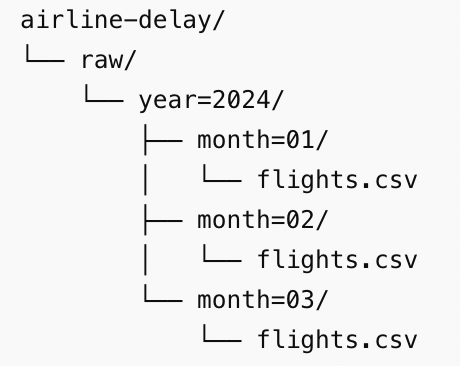

In [12]:
import requests, zipfile, io

files = [
      ("2024_1", "year=2024/month=01"),
      ("2024_2", "year=2024/month=02"),
      ("2024_3", "year=2024/month=03"),
  ]

base_url = "https://transtats.bts.gov/PREZIP/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_{}.zip"

for suffix, s3_prefix in files:
  url = base_url.format(suffix)
  print(f"Downloading {suffix}...")

  r = requests.get(url, timeout=120)
  r.raise_for_status()

  z = zipfile.ZipFile(io.BytesIO(r.content))
  csv_name = [n for n in z.namelist() if n.endswith(".csv")][0]
  csv_bytes = z.read(csv_name)

  key = f"airline-delay/raw/{s3_prefix}/flights.csv"
  s3_client.put_object(Bucket=bucket, Key=key, Body=csv_bytes)
  print(f"  uploaded → s3://{bucket}/{key} ({len(csv_bytes)//1_000_000} MB)")
      
  print("\nDone. All 3 months in S3.")


  uploaded → s3://sagemaker-us-east-1-103012382341/airline-delay/raw/year=2024/month=01/flights.csv (246 MB)

Done. All 3 months in S3.


  uploaded → s3://sagemaker-us-east-1-103012382341/airline-delay/raw/year=2024/month=02/flights.csv (234 MB)

Done. All 3 months in S3.


  uploaded → s3://sagemaker-us-east-1-103012382341/airline-delay/raw/year=2024/month=03/flights.csv (267 MB)

Done. All 3 months in S3.


In [15]:
!aws s3 ls $s3_aerodelay --recursive

2026-05-26 19:55:25  246830488 airline-delay/raw/year=2024/month=01/flights.csv
2026-05-26 19:55:38  234405431 airline-delay/raw/year=2024/month=02/flights.csv
2026-05-26 19:55:52  267667796 airline-delay/raw/year=2024/month=03/flights.csv
